<a href="https://colab.research.google.com/github/siccd143/BorrowBoard-YouthxCode/blob/main/model-train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install roboflow ultralytics tensorflowjs -q

import os
from google.colab import userdata
from roboflow import Roboflow
from torch.utils.data import DataLoader
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.41.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
db-dtypes 1.7.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
bigquer

In [3]:
rf = Roboflow(api_key=userdata.get('RoboflowAPIKey'))
project = rf.workspace("duc-nguyen-asf36").project("school-supplies-gz456")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to school-supplies-1 in yolov8:: 100%|██████████| 15915/15915 [00:02<00:00, 7731.64it/s] 


In [4]:
import os
model = YOLO('yolo26n.pt')
data_yaml_path = os.path.join('/content', project.name.replace(' ', '-') + '-' + str(version.version), 'data.yaml')
results = model.train(data=data_yaml_path, epochs=32, imgsz=640, batch=-1, device=0)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/school-supplies-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=32, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

In [8]:
model.export(format="tfjs", imgsz=640)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.6s, saved as '/content/runs/detect/train/weights/best.onnx' (9.4 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/content/runs/detect/train/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 300, 6), dtype=tf.float32, name=None)
Captures:
  140118861719568: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  140118861718992: TensorSpec(shape=(3, 3, 3, 16),

'/content/runs/detect/train/weights/best_web_model/'


Found https://i.pinimg.com/736x/d0/6b/77/d06b77a50b6c6b113b19ad78f86978cb.jpg locally at d06b77a50b6c6b113b19ad78f86978cb.jpg
image 1/1 /content/d06b77a50b6c6b113b19ad78f86978cb.jpg: 640x448 1 scissors, 68.0ms
Speed: 17.9ms preprocess, 68.0ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/detect/predict


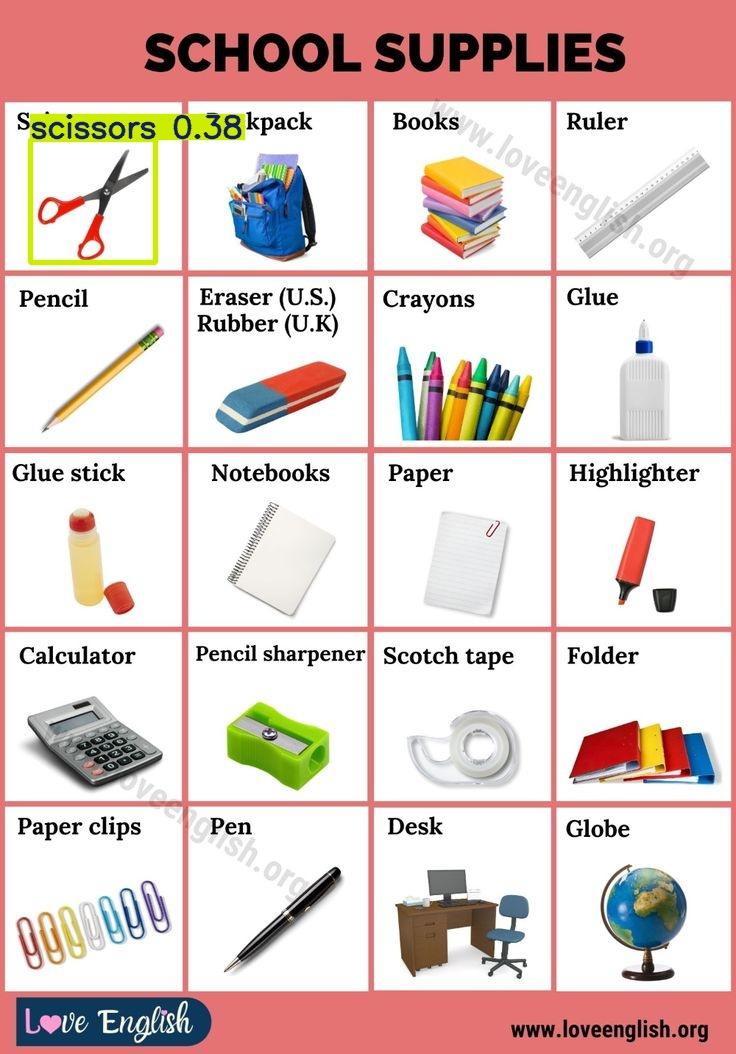

In [7]:
from IPython.display import Image, display

results = model.predict(source='https://i.pinimg.com/736x/d0/6b/77/d06b77a50b6c6b113b19ad78f86978cb.jpg', save=True)
display(Image(filename='runs/detect/predict/d06b77a50b6c6b113b19ad78f86978cb.jpg'))